In [5]:
%matplotlib widget

In [ ]:
from zarr_store import ZarrStore
import matplotlib.pyplot as plt
import ipywidgets as widgets
import einops

In [7]:
store = ZarrStore.create('../../../../../out/AutoEncoder')
display(store.create_ui())

NameError: name 'einops' is not defined

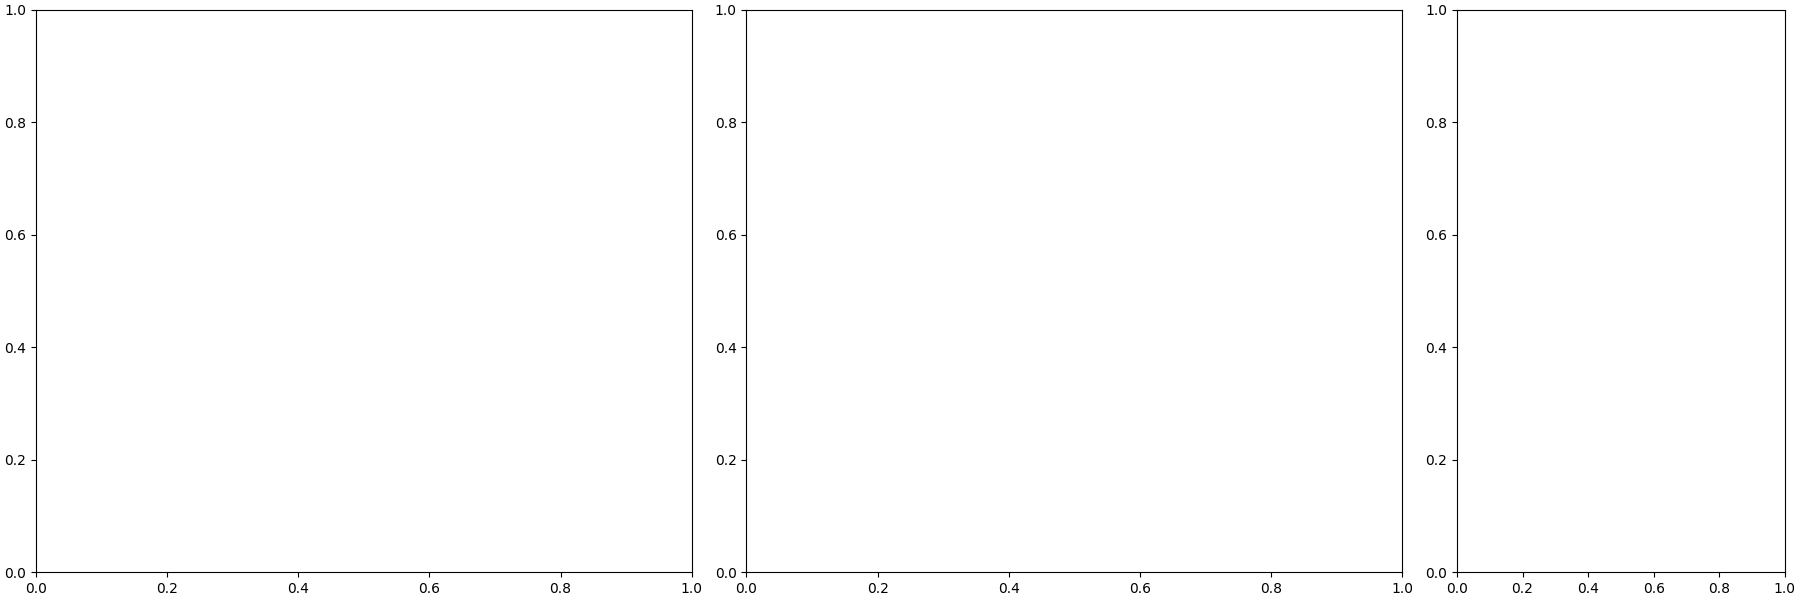

In [8]:
def visualize_with_latent_animated(run_name: str):
    # 1. Load Data
    recon_data = store.load_metric('reconstructed')
    latent_data = store.load_metric('latent')
    orig_data = store.load_metric('original')
    
    steps, raw_recon = recon_data[run_name]
    _, raw_latent = latent_data[run_name]
    _, raw_orig = orig_data[run_name]
    
    num_steps = len(steps)
    latent_dim = raw_latent.shape[-1]

    # 2. Helpers
    def get_grid(tensor_batch):
        return einops.rearrange(tensor_batch, "(gh gw) ph pw -> (gh ph) (gw pw)", gh=8, gw=8)

    # 3. UI Elements (The Animation Engine)
    play = widgets.Play(
        value=0,
        min=0,
        max=num_steps - 1,
        step=1,
        interval=100, # Speed in milliseconds
        description="Press play",
        disabled=False
    )
    slider = widgets.IntSlider(min=0, max=num_steps - 1, description='Step')
    speed_input = widgets.IntSlider(value=100, min=50, max=1000, step=50, description='Speed (ms)')

    # --- THE MAGIC LINK ---
    # This connects the Play button's internal counter to the Slider's value
    widgets.jslink((play, 'value'), (slider, 'value'))
    # This lets you change the play speed on the fly
    widgets.jslink((speed_input, 'value'), (play, 'interval'))

    # 4. Initialize Plot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), 
                                        gridspec_kw={'width_ratios': [1, 1, 0.5]},
                                        constrained_layout=True)
    
    ax1.imshow(get_grid(raw_orig[0]), cmap='gray')
    ax1.set_title("Original")
    ax1.axis('off')
    
    im_recon = ax2.imshow(get_grid(raw_recon[0]), cmap='gray')
    ax2.set_title(f"Reconstruction | Step: {steps[0]}")
    ax2.axis('off')
    
    im_latent = ax3.imshow(raw_latent[0], aspect='auto', cmap='magma')
    fig.colorbar(im_latent, ax=ax3, label='Activation')
    ax3.set_title(f"Latent ({latent_dim}d)")

    # 5. Update Function
    def update(change):
        idx = change['new'] if isinstance(change, dict) else change
        im_recon.set_data(get_grid(raw_recon[idx]))
        im_latent.set_data(raw_latent[idx])
        ax2.set_title(f"Reconstruction | Step: {steps[idx]}")
        fig.canvas.draw_idle()

    slider.observe(update, names='value')

    # 6. Layout (Arrange buttons and plot)
    controls = widgets.HBox([play, slider, speed_input])
    ui = widgets.VBox([controls, fig.canvas])
    
    display(ui)

# Usage
visualize_with_latent_animated(store.run_names[0])